<a href="https://colab.research.google.com/github/Ida-code/Potato-plant-Leaf-Disease-detection-/blob/main/Final_Trained_CNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Data Preprocessing (Original work by Collaborator's Name) The cells containing the data loading and initial preprocessing steps developed by https://github.com/ArunimaSanjeev.



In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow.keras import models,layers

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/My_project/PlantVillage"))



['Early_blight', 'healthy', 'Late_blight']


In [ ]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/My_project/PlantVillage",
    shuffle=True,
    image_size=(256, 256), #all image size is 256*256 go and verify
    batch_size=32  #standard batch size
)


Found 2152 files belonging to 3 classes.


In [ ]:
class_names = dataset.class_names
class_names

['Early_blight', 'Late_blight', 'healthy']

In [ ]:
len(dataset)

68

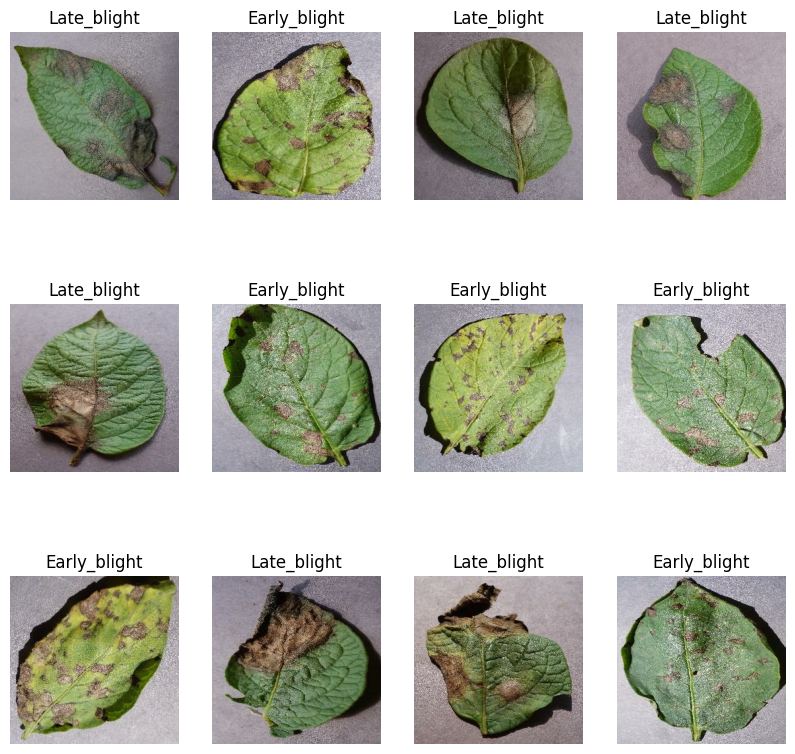

In [ ]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
  for i in range(12):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[labels_batch[i]])
    plt.axis("off")

In [ ]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [ ]:
train_ds = dataset.take(54) #first 54 like [:54]
len(train_ds)

54

In [ ]:
test_ds = dataset.skip(54) #skipping first 54
len(test_ds)

14

In [ ]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [ ]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [ ]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [ ]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)

    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds


In [ ]:
train_ds, val_ds, test_ds= get_dataset_partitions_tf(dataset)

In [ ]:
len(val_ds)

6

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/content/drive/MyDrive/My_/ISIC_Melanoma_Data',
    target_size=(224, 224),
    batch_size=32
)

# Check the class indices and the number of samples per class
from collections import Counter
counter = Counter(train_gen.classes)
print(f"Class counts: {counter}")

Found 2152 images belonging to 3 classes.
Class counts: Counter({np.int32(0): 1000, np.int32(1): 1000, np.int32(2): 152})


In [ ]:

from tensorflow.keras import layers, models

IMAGE_SIZE = 256
CHANNELS = 3
n_classes = 3

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
])
data_augmentation1 = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),


    resize_and_rescale,
    data_augmentation1,

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax"),
])

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

all_labels = []

for images, labels in train_ds:
    all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.7218045112781954), 1: np.float64(0.7164179104477612), 2: np.float64(4.571428571428571)}


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
history=model.fit(
    train_ds,
    epochs=50,
    class_weight=class_weights,
    batch_size=32,
    verbose=1,
    validation_data=val_ds
)




Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.3317 - loss: 1.1803 - val_accuracy: 0.4583 - val_loss: 1.0893
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.4565 - loss: 1.0657 - val_accuracy: 0.4479 - val_loss: 1.0951
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.4435 - loss: 1.0793 - val_accuracy: 0.4635 - val_loss: 1.0855
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.5035 - loss: 1.0497 - val_accuracy: 0.4896 - val_loss: 1.0544
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.5716 - loss: 0.9514 - val_accuracy: 0.7188 - val_loss: 1.0087
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.5637 - loss: 0.8007 - val_accuracy: 0.6562 - val_loss: 0.8662
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.6849 - loss: 0.6064 - val_accuracy: 0.7656 - val_loss: 0.6921
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.6905 - loss: 0.5578 - val_accuracy: 

In [ ]:
scores=model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9436 - loss: 0.2121


In [ ]:
scores

[0.2259097397327423, 0.93359375]

In [ ]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss']

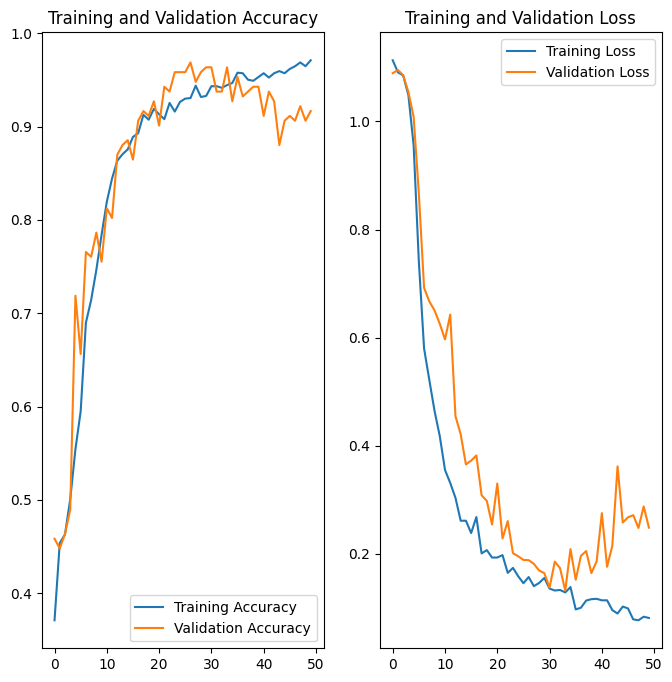

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(50), acc, label='Training Accuracy')
plt.plot(range(50), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(50), loss, label='Training Loss')
plt.plot(range(50), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


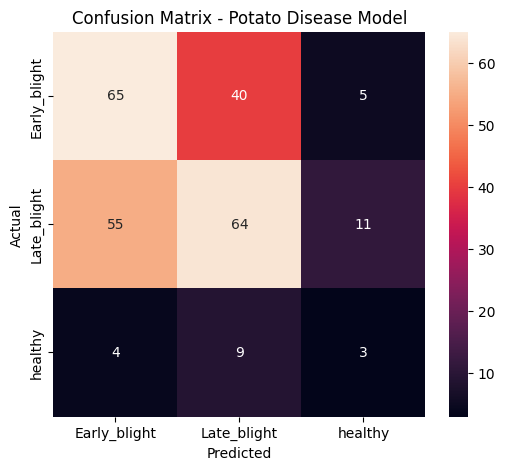

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Extract true labels from test_ds
y_true = []
for images, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Predict from model
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Potato Disease Model")
plt.show()